In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv("advertising.csv")

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [12]:
X = df[['TV','Radio','Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Baseline R2 Score:", r2_score(y_test, y_pred))
print("Baseline MSE:", mean_squared_error(y_test, y_pred))

Baseline R2 Score: 0.9059011844150826
Baseline MSE: 2.9077569102710896


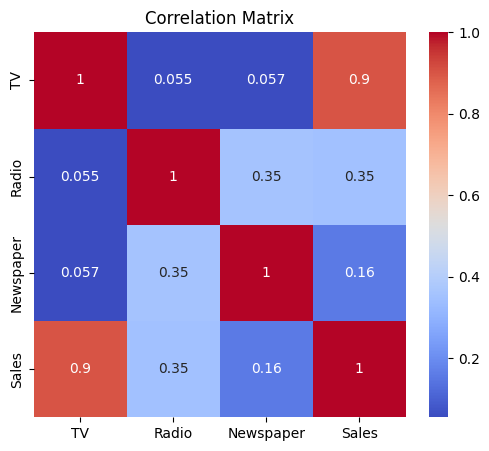

In [4]:
corr = df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [13]:
X_vif = X.copy()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

print(vif_data)

     Feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


In [14]:
#there is no severe multicollinearity so there is no need to remove any feature as the vif value is less than  5

In [ ]:
Why multicollinearity is harmful?
Multicollinearity makes it hard to separate the effect of each feature since they are highly correlated
this leads to unstable models and unreliable interpretations

In [ ]:
How it affects coefficients
Coefficients become unstable, change drastically with small data changes, and may get incorrect signs
their standard errors increase, making variables appear insignificant.

In [ ]:
How removing features improved model
Removing correlated features reduces redundancy and stabilizes coefficient values
this improves interpretability, reduces variance, and enhances model performance.